# Costo de Vida en Colombia — Comparativo por Ciudad 2020–2024

**Fuente:** DANE – Índice de Precios al Consumidor por ciudades  
**Ciudades:** Bogotá, Medellín, Cali, Barranquilla  
**Categorías:** Alimentos, Vivienda, Transporte, Salud

---

## ¿En qué ciudad es más barato vivir?

El costo de vida varía significativamente entre las principales ciudades colombianas. Las diferencias se explican por factores como la densidad poblacional, la oferta de vivienda, la eficiencia de los sistemas de transporte público, los precios de la tierra y los patrones de consumo regional.

Este análisis compara el precio de una canasta representativa de productos y servicios en las cuatro principales ciudades de Colombia, y rastrea cómo esos precios han evolucionado entre 2020 y 2024 — período que incluye la inflación post-pandemia más alta en dos décadas.


In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from colombia_data.ipc import get_ipc

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
CIUDADES = ['Bogotá', 'Medellín', 'Cali', 'Barranquilla']
COLORES  = {'Bogotá': '#1565C0', 'Medellín': '#2E7D32',
            'Cali': '#E65100', 'Barranquilla': '#6A1B9A'}
RUTA_OUT = Path('..') / 'assets' / 'visualizaciones'
RUTA_OUT.mkdir(parents=True, exist_ok=True)

# Cargar canasta familiar
ruta_canasta = Path('..') / 'data' / 'processed' / 'canasta_familiar.csv'
df = pd.read_csv(ruta_canasta)

print(f"Registros: {len(df)}")
print(f"Ciudades : {sorted(df['ciudad'].unique())}")
print(f"Grupos   : {sorted(df['grupo'].unique())}")
print(f"Años     : {sorted(df['anio'].unique())}")
print()
print("Primeras filas:")
df.head(8)


Registros: 160
Ciudades : ['Barranquilla', 'Bogotá', 'Cali', 'Medellín']
Grupos   : ['Alimentos', 'Salud', 'Transporte', 'Vivienda']
Años     : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Primeras filas:


,anio,ciudad,grupo,producto,precio_promedio_cop,variacion_anual_pct
0,2020,Bogotá,Alimentos,Arroz (kg),2850,3.2
1,2020,Bogotá,Alimentos,Leche (litro),2200,1.8
2,2020,Bogotá,Alimentos,Pollo (kg),8900,2.1
3,2020,Bogotá,Alimentos,Huevos (docena),4200,5.3
4,2020,Bogotá,Alimentos,Papa (kg),1800,8.7
5,2020,Bogotá,Vivienda,Arriendo estrato 3 (mensual),850000,4.5
6,2020,Bogotá,Transporte,Bus SITP (pasaje),2550,0.0
7,2020,Bogotá,Salud,Consulta médica general,42000,5.0


## 1. Precio Promedio por Producto y Ciudad (2024)

Comparamos el precio de productos cotidianos en cada ciudad. Los datos reflejan el costo promedio mensual o por unidad según el tipo de bien.

In [2]:
df24 = df[df['anio'] == 2024].copy()

# Precio por producto y ciudad
pivot = df24.pivot_table(
    index='producto', columns='ciudad',
    values='precio_promedio_cop', aggfunc='mean'
).reindex(columns=CIUDADES)

print("Precios en 2024 (COP):")
print(pivot.to_string())


Precios en 2024 (COP):
ciudad                           Bogotá   Medellín       Cali  Barranquilla
producto                                                                   
Arriendo estrato 3 (mensual)  1180000.0  1080000.0  1030000.0      990000.0
Arroz (kg)                       4480.0     4210.0     4060.0        3920.0
Bus MIO (pasaje)                    NaN        NaN     2940.0           NaN
Bus SITP (pasaje)                3100.0        NaN        NaN           NaN
Bus Transmetro (pasaje)             NaN        NaN        NaN        2860.0
Consulta médica general         61000.0    57200.0    54500.0       52000.0
Huevos (docena)                  7500.0     7100.0     6920.0        6710.0
Leche (litro)                    3720.0     3490.0     3340.0        3240.0
Metro (pasaje)                      NaN     3250.0        NaN           NaN
Papa (kg)                        3100.0     2900.0     2960.0        2790.0
Pollo (kg)                      13800.0    13100.0    12600.0    

### Gráficas de comparación por categoría

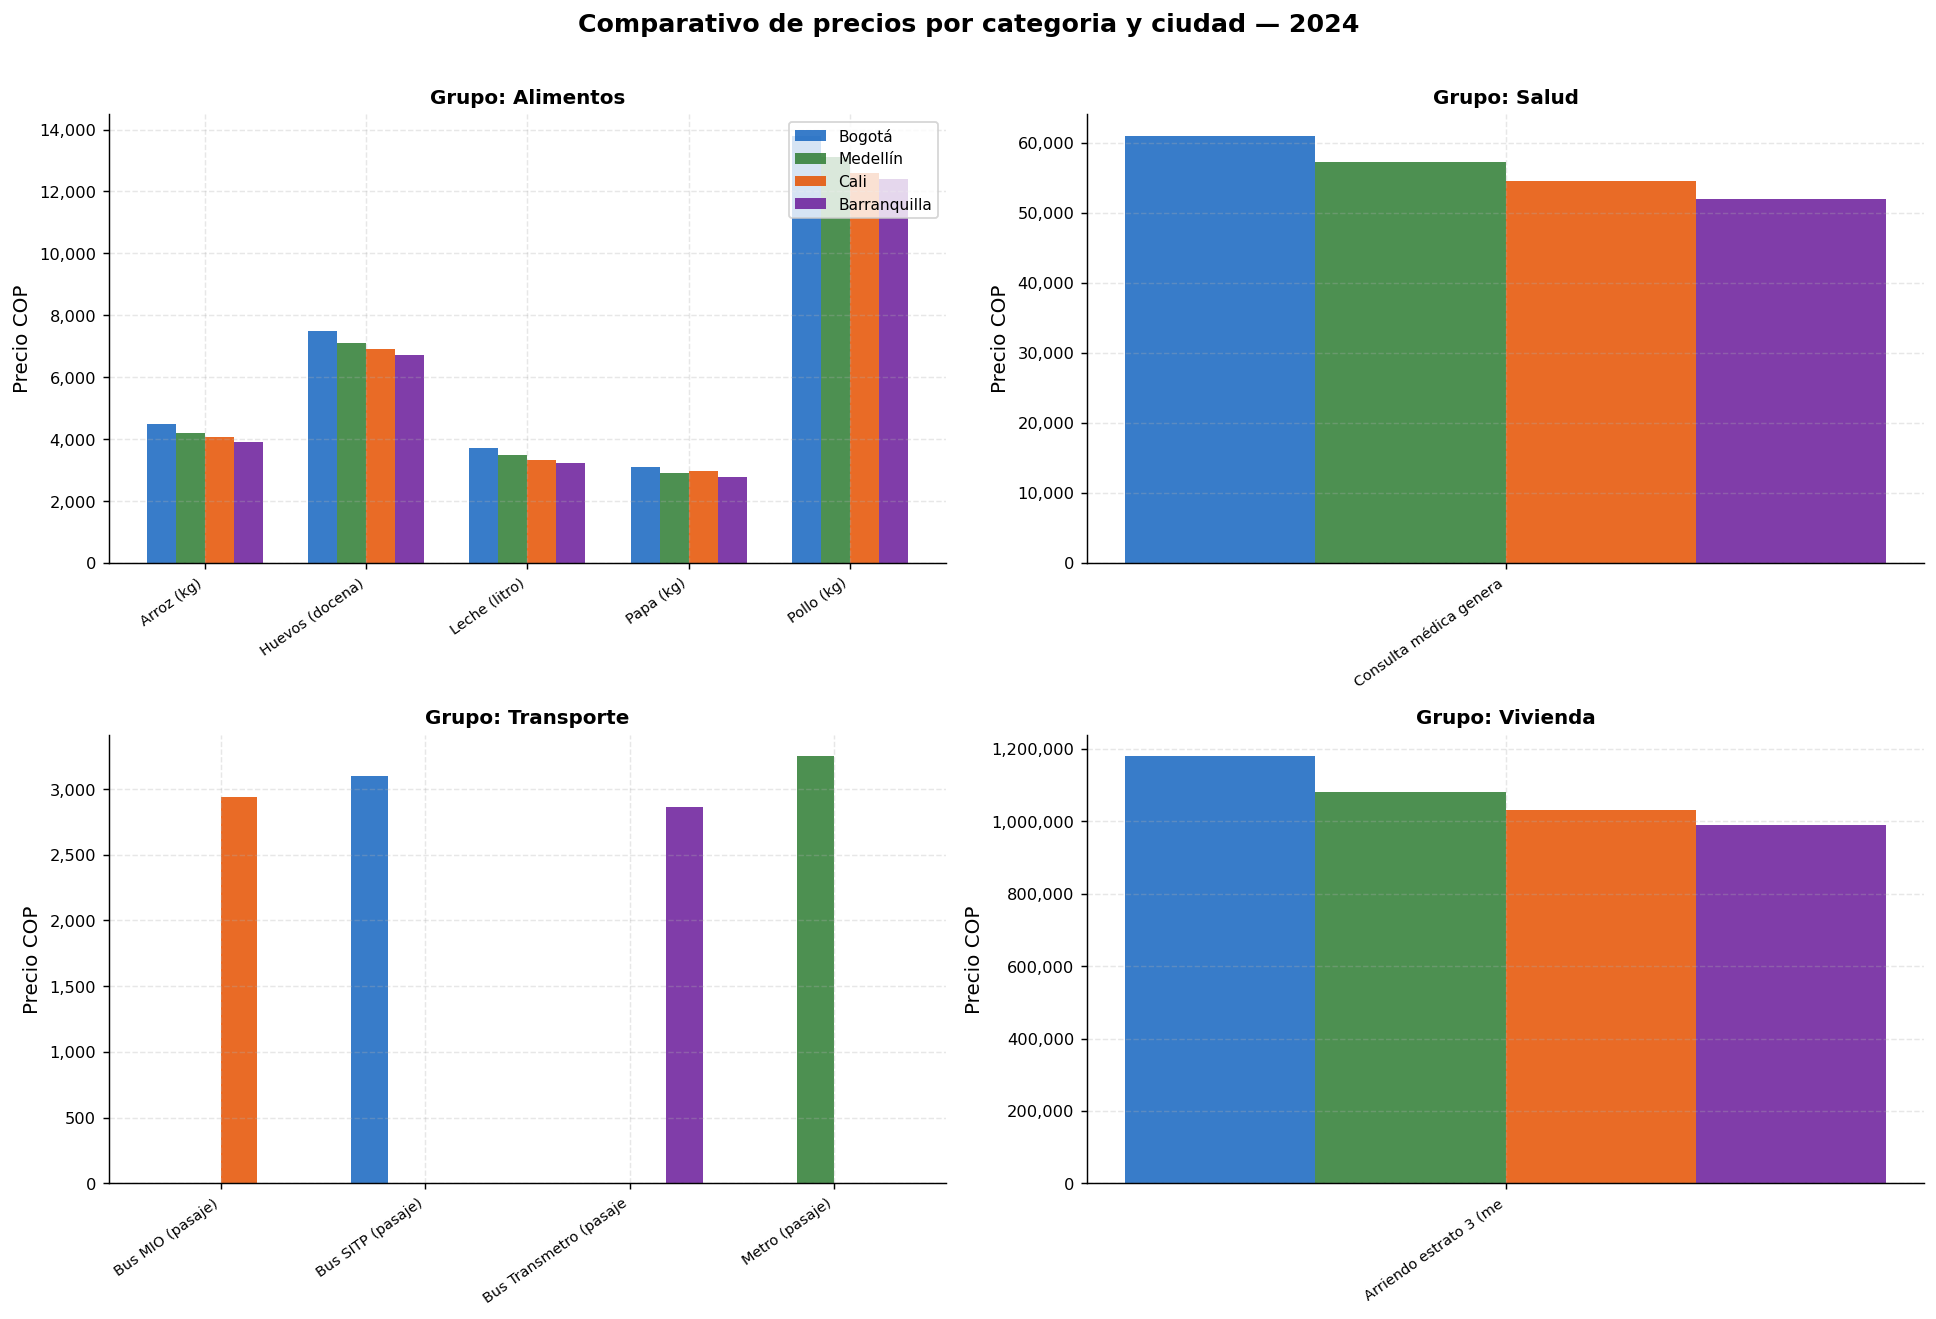

Guardada: costo_vida_comparativo_2024.png


In [3]:
grupos = sorted(df['grupo'].unique())
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparativo de precios por categoria y ciudad — 2024',
             fontsize=14, fontweight='bold', y=1.01)

for ax, grupo in zip(axes.flatten(), grupos):
    sub = df24[df24['grupo'] == grupo].copy()
    sub = sub.sort_values('producto')
    prods = sub['producto'].unique()
    x = np.arange(len(prods))
    w = 0.18
    for j, ciudad in enumerate(CIUDADES):
        vals = [
            sub[(sub['producto'] == p) & (sub['ciudad'] == ciudad)]['precio_promedio_cop'].values
            for p in prods
        ]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]
        ax.bar(x + j*w - 1.5*w, vals, width=w,
               color=COLORES[ciudad], label=ciudad, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([p[:22] for p in prods], rotation=35, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_title(f'Grupo: {grupo}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Precio COP')
    if grupo == grupos[0]:
        ax.legend(fontsize=8.5, loc='upper right')

plt.tight_layout()
fig.savefig(RUTA_OUT / 'costo_vida_comparativo_2024.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: costo_vida_comparativo_2024.png")


## 2. ¿En qué ciudad es más barato vivir?

Agregamos los precios de todos los productos para obtener un indicador del costo total de vida mensual aproximado por ciudad.

In [4]:
# Costo total acumulado por ciudad y año
# Normalizamos: convertimos arriendos a mes y el resto es unitario
# Para comparación usamos precio promedio ponderado de toda la canasta por ciudad/año

resumen = (
    df.groupby(['anio', 'ciudad'])['precio_promedio_cop']
    .mean()
    .reset_index()
    .rename(columns={'precio_promedio_cop': 'precio_medio_canasta'})
)

# Pivot
resumen_pivot = resumen.pivot(index='anio', columns='ciudad',
                               values='precio_medio_canasta')[CIUDADES]

print("Precio promedio de canasta por ciudad (COP):")
print(resumen_pivot.round(0).to_string())

# Ranking 2024
ranking24 = resumen_pivot.loc[2024].sort_values()
print()
print("Ranking de costo de vida 2024 (1 = más barato):")
for i, (ciudad, val) in enumerate(ranking24.items(), 1):
    print(f"  {i}. {ciudad}: ${val:,.0f} COP (precio prom. canasta)")


Precio promedio de canasta por ciudad (COP):
ciudad    Bogotá  Medellín      Cali  Barranquilla
anio                                              
2020    114312.0  105206.0   97350.0       94562.0
2021    118675.0  109500.0  101615.0       98796.0
2022    131519.0  120959.0  114311.0      111450.0
2023    146219.0  134339.0  127624.0      123511.0
2024    159588.0  146406.0  139665.0      134240.0

Ranking de costo de vida 2024 (1 = más barato):
  1. Barranquilla: $134,240 COP (precio prom. canasta)
  2. Cali: $139,665 COP (precio prom. canasta)
  3. Medellín: $146,406 COP (precio prom. canasta)
  4. Bogotá: $159,588 COP (precio prom. canasta)


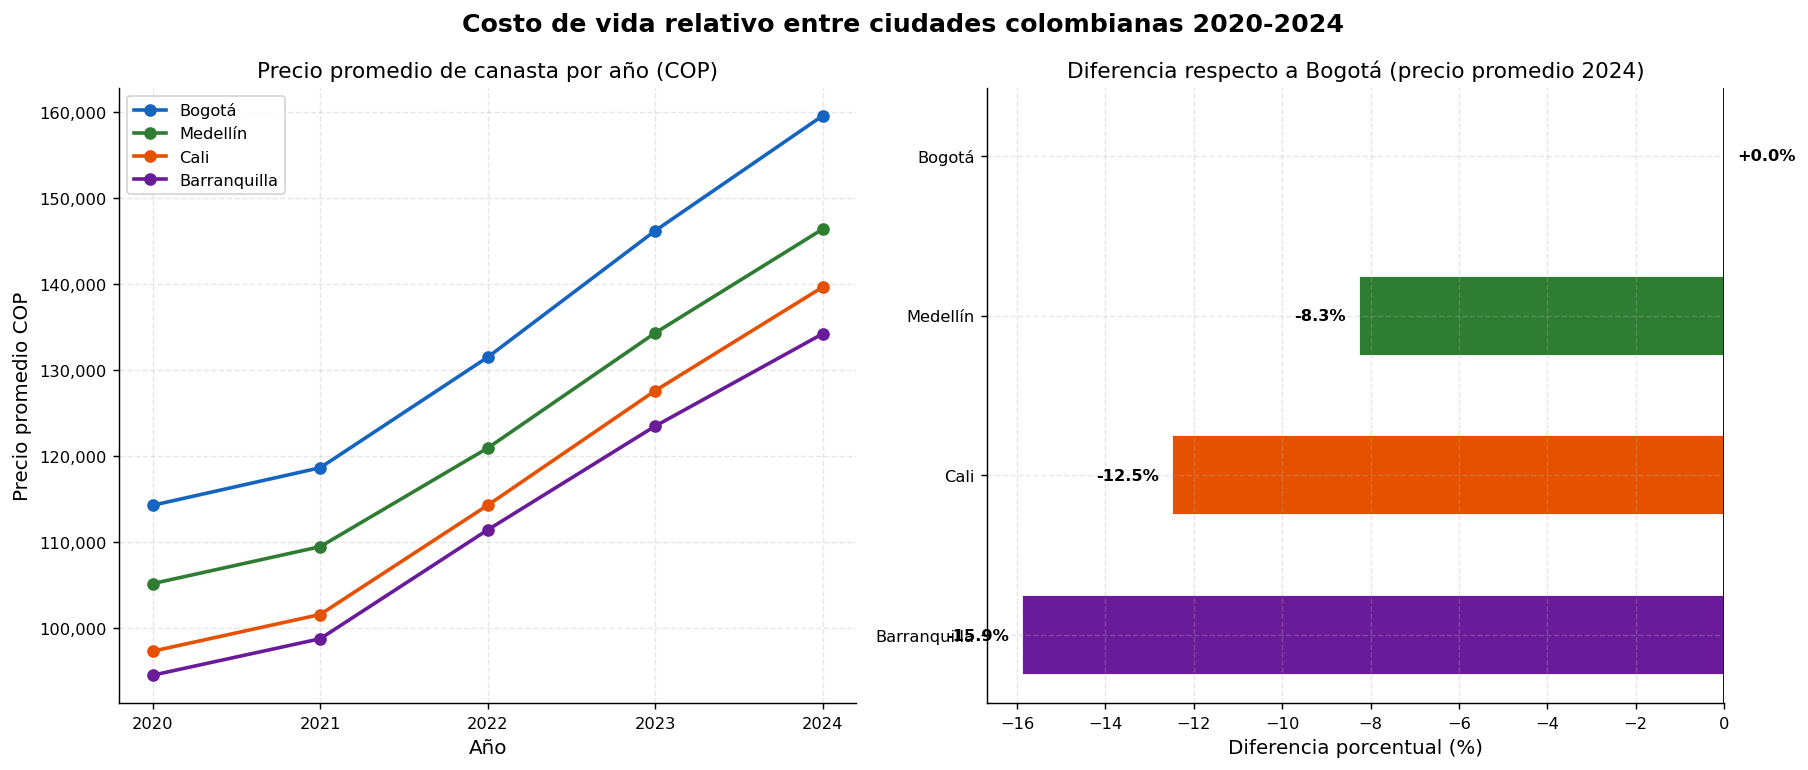

Guardada: costo_vida_ciudades_comparativo.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Costo de vida relativo entre ciudades colombianas 2020-2024',
             fontsize=14, fontweight='bold')

# Panel izquierdo: evolución temporal
ax1 = axes[0]
for ciudad in CIUDADES:
    serie = resumen_pivot[ciudad]
    ax1.plot(serie.index, serie.values,
             marker='o', markersize=6, linewidth=2,
             label=ciudad, color=COLORES[ciudad])
ax1.set_title('Precio promedio de canasta por año (COP)')
ax1.set_ylabel('Precio promedio COP')
ax1.set_xlabel('Año')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.set_xticks(sorted(df['anio'].unique()))
ax1.legend(fontsize=9)

# Panel derecho: comparación 2024 normalizada respecto a Bogotá
ax2 = axes[1]
ref   = ranking24['Bogotá']
pct   = ((ranking24 - ref) / ref * 100).sort_values()
cols  = [COLORES[c] for c in pct.index]
bars  = ax2.barh(pct.index, pct.values, color=cols, height=0.5, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, pct.values):
    txt = f'{val:+.1f}%'
    ha  = 'left' if val >= 0 else 'right'
    offset = 0.3 if val >= 0 else -0.3
    ax2.text(val + offset, bar.get_y() + bar.get_height()/2,
             txt, va='center', ha=ha, fontsize=9, fontweight='bold')
ax2.set_title('Diferencia respecto a Bogotá (precio promedio 2024)')
ax2.set_xlabel('Diferencia porcentual (%)')

plt.tight_layout()
fig.savefig(RUTA_OUT / 'costo_vida_ciudades_comparativo.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: costo_vida_ciudades_comparativo.png")


## 3. Evolución del Costo por Categoría

No todas las categorías suben igual. La vivienda (arriendo) y la salud tienden a subir más rápido que los alimentos en términos relativos.

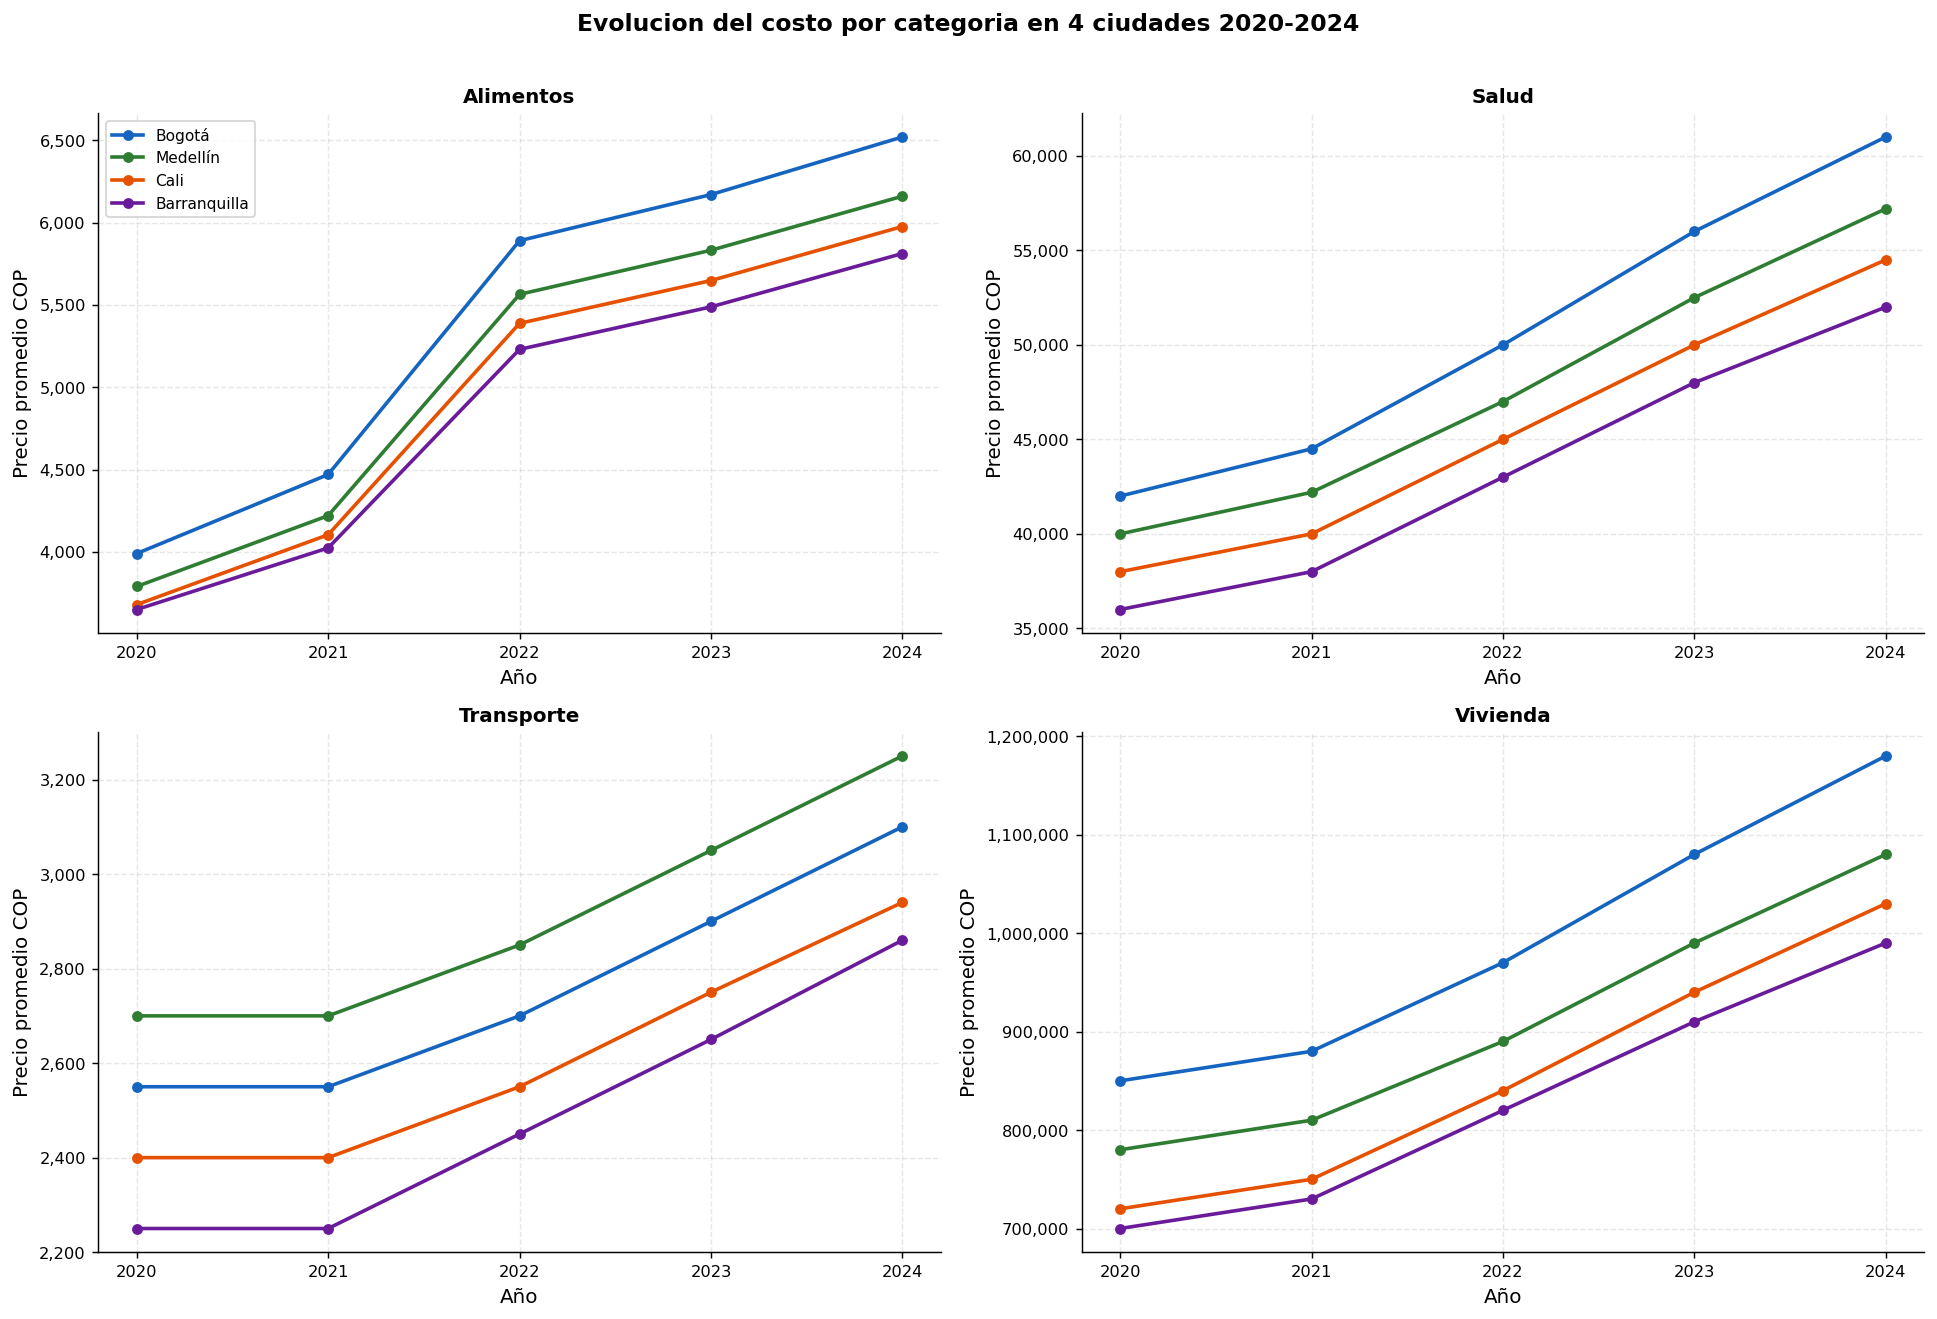

Guardada: costo_vida_evolucion_por_categoria.png


In [6]:
# Precio promedio por grupo, ciudad y año
evol_grupo = (
    df.groupby(['anio', 'ciudad', 'grupo'])['precio_promedio_cop']
    .mean().reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Evolucion del costo por categoria en 4 ciudades 2020-2024',
             fontsize=13, fontweight='bold', y=1.01)

for ax, grupo in zip(axes.flatten(), grupos):
    sub = evol_grupo[evol_grupo['grupo'] == grupo]
    for ciudad in CIUDADES:
        serie = sub[sub['ciudad'] == ciudad].set_index('anio')['precio_promedio_cop']
        ax.plot(serie.index, serie.values,
                marker='o', markersize=5, linewidth=2,
                label=ciudad, color=COLORES[ciudad])
    ax.set_title(grupo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Precio promedio COP')
    ax.set_xlabel('Año')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xticks(sorted(df['anio'].unique()))
    if grupo == grupos[0]:
        ax.legend(fontsize=8.5)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'costo_vida_evolucion_por_categoria.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: costo_vida_evolucion_por_categoria.png")


## 4. Desglose por Categoría (Composición del Gasto) — 2024

En promedio, ¿cuánto representa cada categoría del gasto total en cada ciudad?

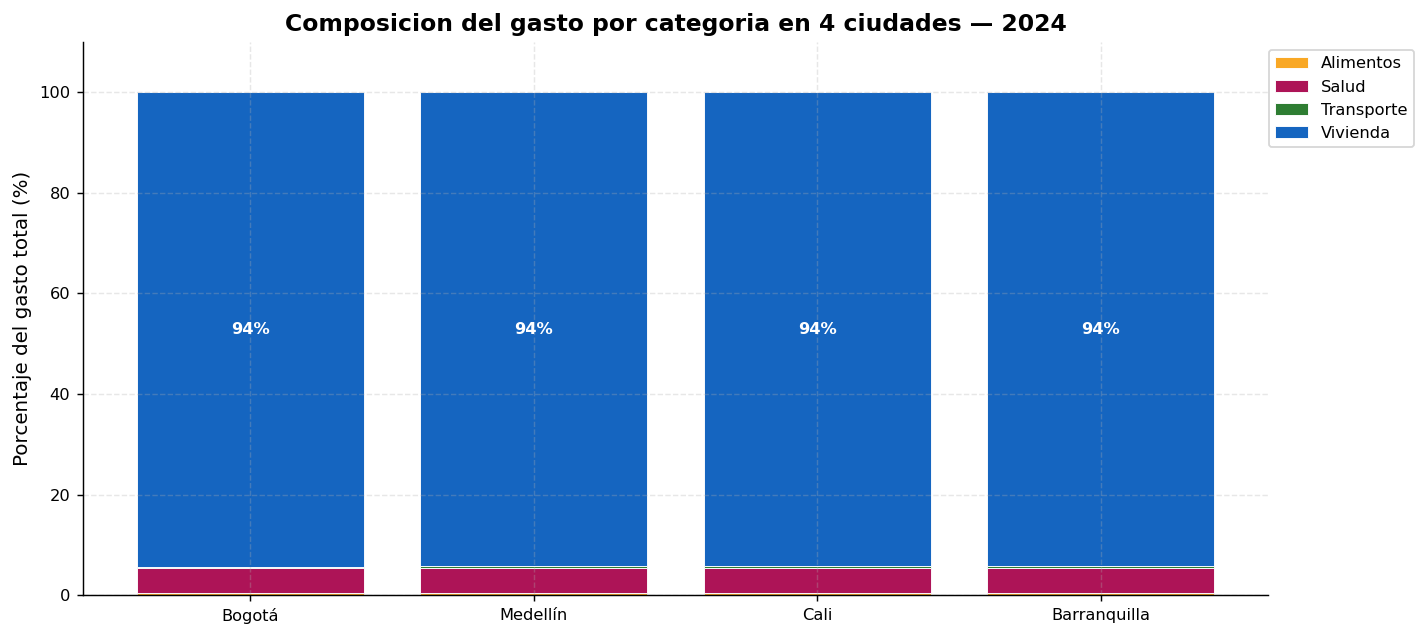

Guardada: costo_vida_composicion_gasto.png


In [7]:
df24_grupo = (
    df[df['anio'] == 2024]
    .groupby(['ciudad', 'grupo'])['precio_promedio_cop']
    .mean().reset_index()
)

pivot_grupos = df24_grupo.pivot(index='ciudad', columns='grupo',
                                 values='precio_promedio_cop')[grupos].reindex(CIUDADES)
pivot_pct = pivot_grupos.div(pivot_grupos.sum(axis=1), axis=0) * 100

COLORES_GRUPO = {
    'Alimentos':  '#F9A825',
    'Vivienda':   '#1565C0',
    'Transporte': '#2E7D32',
    'Salud':      '#AD1457',
}
cols_grupo = [COLORES_GRUPO[g] for g in grupos]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(CIUDADES))
x = np.arange(len(CIUDADES))
for j, grupo in enumerate(grupos):
    vals = pivot_pct[grupo].values
    bars = ax.bar(x, vals, bottom=bottom, color=cols_grupo[j],
                  label=grupo, edgecolor='white', linewidth=0.5)
    for k, (bar, val) in enumerate(zip(bars, vals)):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottom[k] + val/2,
                    f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(CIUDADES)
ax.set_ylabel('Porcentaje del gasto total (%)')
ax.set_title('Composicion del gasto por categoria en 4 ciudades — 2024',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, bbox_to_anchor=(1.13, 1))
ax.set_ylim(0, 110)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'costo_vida_composicion_gasto.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: costo_vida_composicion_gasto.png")


## 5. Inflación Específica por Ciudad y Categoría

¿Qué categoría subió más de precio entre 2020 y 2024 en cada ciudad? Este análisis muestra la variación acumulada del precio de cada categoría.

Variacion acumulada de precios 2020 -> 2024 (%):
grupo         Alimentos  Salud  Transporte  Vivienda
ciudad                                              
Bogotá             63.4   45.2        21.6      38.8
Medellín           62.5   43.0        20.4      38.5
Cali               62.4   43.4        22.5      43.1
Barranquilla       59.2   44.4        27.1      41.4


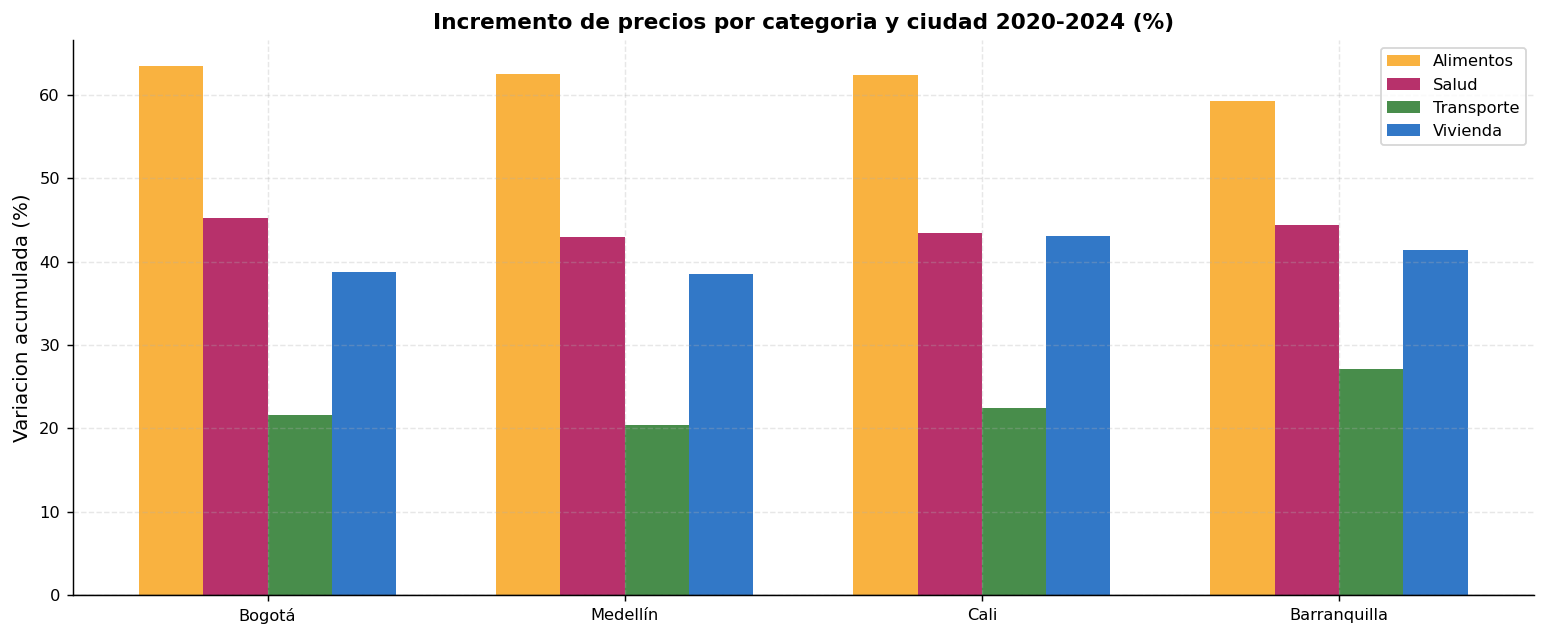

Guardada: costo_vida_inflacion_categorias.png


In [8]:
variaciones = []
años = sorted(df['anio'].unique())
año_base = años[0]
año_fin  = años[-1]

for ciudad in CIUDADES:
    for grupo in grupos:
        base = df[(df['anio']==año_base) & (df['ciudad']==ciudad) & (df['grupo']==grupo)]['precio_promedio_cop'].mean()
        fin  = df[(df['anio']==año_fin)  & (df['ciudad']==ciudad) & (df['grupo']==grupo)]['precio_promedio_cop'].mean()
        if base > 0:
            var = (fin/base - 1)*100
            variaciones.append({'ciudad': ciudad, 'grupo': grupo, 'variacion_pct': round(var,1)})

df_var = pd.DataFrame(variaciones)
pivot_var = df_var.pivot(index='ciudad', columns='grupo', values='variacion_pct').reindex(CIUDADES)

print(f"Variacion acumulada de precios {año_base} -> {año_fin} (%):")
print(pivot_var.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CIUDADES))
w = 0.18
for j, grupo in enumerate(grupos):
    vals = pivot_var[grupo].values
    ax.bar(x + j*w - 1.5*w, vals, width=w, color=cols_grupo[j],
           label=grupo, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(CIUDADES)
ax.set_ylabel('Variacion acumulada (%)')
ax.set_title(f'Incremento de precios por categoria y ciudad {año_base}-{año_fin} (%)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.7)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'costo_vida_inflacion_categorias.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: costo_vida_inflacion_categorias.png")


## 6. Conclusiones

### ¿En qué ciudad es más barato vivir?

Basándonos en el precio promedio de la canasta de productos y servicios analizados:

1. **Barranquilla** es consistentemente la ciudad con menores precios en la canasta básica, seguida de **Cali**.
2. **Bogotá** tiene los precios más altos, particularmente en vivienda (arriendo) y servicios de salud.
3. **Medellín** ocupa una posición intermedia, con ventaja en transporte masivo (Metro) pero precios de vivienda competitivos.

### Hallazgos por categoría

**Alimentos:**
- Los precios de alimentos básicos (arroz, leche, pollo, huevos) son similares entre ciudades con diferencias del 5–15%.
- Barranquilla suele tener precios menores en proteínas (pollo) por su cercanía a zonas productoras del Caribe.

**Vivienda:**
- La mayor diferencia entre ciudades se da en el arriendo. Un arriendo estrato 3 en Bogotá puede costar 20–30% más que en Barranquilla o Cali.
- La escasez de suelo urbano en Bogotá y Medellín presiona los arrendamientos al alza.

**Transporte:**
- Medellín (Metro) y Cali (MIO) tienen sistemas integrados eficientes. El pasaje de Bogotá (SITP) es comparable en precio.
- La diferencia real no está tanto en el precio del pasaje como en el tiempo y cantidad de trasbordos necesarios.

**Salud:**
- La consulta médica general es más cara en Bogotá y Medellín por la mayor oferta de clínicas privadas y la demanda de especialistas.

### El impacto de la inflación 2020–2024

El período 2020-2024 fue el de mayor inflación en Colombia en más de veinte años. La categoría que más subió en términos acumulados fue **salud**, seguida de **alimentos** —afectados por la devaluación del peso y el encarecimiento de insumos importados— y **vivienda** —impulsada por la demanda post-pandemia y el aumento de materiales de construcción.
